<div style="font-family: 'Segoe UI', Roboto, Helvetica, Arial, sans-serif; max-width: 800px; margin: 20px auto; background-color: #ffffff; border-radius: 8px; box-shadow: 0 4px 15px rgba(0,0,0,0.1); overflow: hidden; border: 1px solid #e0e0e0;">
    
<div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); padding: 30px; color: white;">
        <h3 style="margin: 0; font-weight: 300; text-transform: uppercase; letter-spacing: 2px; font-size: 0.9rem; opacity: 0.9;">Experiment 08</h3>
        <h1 style="margin: 10px 0 0 0; font-size: 1.8rem; font-weight: 700;">Clustering of Countries</h1>
        <p style="margin: 5px 0 0 0; font-size: 1.1rem; opacity: 0.9; font-weight: 400;">with World Bank API</p>
    </div>

 <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 20px; padding: 25px; background-color: #f8f9fa;">
        
<div style="border-left: 4px solid #2a5298; padding-left: 15px;">
            <span style="display: block; font-size: 0.75rem; color: #666; text-transform: uppercase; letter-spacing: 1px; font-weight: bold;">Student Name</span>
            <span style="font-size: 1.1rem; color: #333; font-weight: 600;">Shravan More</span>
        </div>

<div style="border-left: 4px solid #2a5298; padding-left: 15px;">
            <span style="display: block; font-size: 0.75rem; color: #666; text-transform: uppercase; letter-spacing: 1px; font-weight: bold;">Class / Batch</span>
            <span style="font-size: 1.1rem; color: #333; font-weight: 600;">SE-AIML-B2</span>
        </div>

<div style="border-left: 4px solid #2a5298; padding-left: 15px;">
            <span style="display: block; font-size: 0.75rem; color: #666; text-transform: uppercase; letter-spacing: 1px; font-weight: bold;">Subject</span>
            <span style="font-size: 1.1rem; color: #333; font-weight: 600;">Machine Learning Lab</span>
        </div>

<div style="border-left: 4px solid #2a5298; padding-left: 15px;">
            <span style="display: block; font-size: 0.75rem; color: #666; text-transform: uppercase; letter-spacing: 1px; font-weight: bold;">Date of Performance</span>
            <span style="font-size: 1.1rem; color: #333; font-weight: 600;">12/03/2026</span>
        </div>
    </div>
</div>

### PART 1 : Data Set

In [32]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

In [33]:
def fetch_indicator(code,year="2022"):
    url = f"https://api.worldbank.org/v2/country/all/indicator/{code}?date={year}&format=json&per_page=30000"
    response = requests.get(url).json()[1]

    data = {}
    for item in response:
        country = item['country']['value']
        value = item['value']
        if value is not None:
            data[country] = value
    return pd.Series(data, name=code)

In [34]:
gdp = fetch_indicator("NY.GDP.PCAP.CD")
pop = fetch_indicator("SP.POP.TOTL")
life = fetch_indicator("SP.DYN.LE00.IN")
lit = fetch_indicator("SE.ADT.LITR.ZS")

In [35]:
df = pd.concat([gdp, pop, life, lit], axis=1).dropna()
df.columns = ['GDP', 'Population', 'LifeExpectancy', 'LiteracyRate']

df.dropna(inplace=True)

In [36]:
df.head()

,GDP,Population,LifeExpectancy,LiteracyRate
Africa Eastern and Southern,1679.327622,731821393,64.487020,73.055977
Africa Western and Central,2138.473153,497387180,57.987813,60.780979
Arab World,7950.355820,471352066,71.876096,78.271927
Central Europe and the Baltics,19530.155323,100071871,76.652299,99.479919
Early-demographic dividend,4043.827763,3470644834,71.430455,81.242798


In [37]:
df.tail()

,GDP,Population,LifeExpectancy,LiteracyRate
Uruguay,20818.614609,3390913,76.468,98.849998
Uzbekistan,2578.666894,34938955,72.147,100.000000
Viet Nam,4147.697772,99680655,74.502,96.129997
West Bank and Gaza,3799.955270,5043612,76.662,97.839996
Zambia,1447.123101,20152938,65.279,79.975143


In [38]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

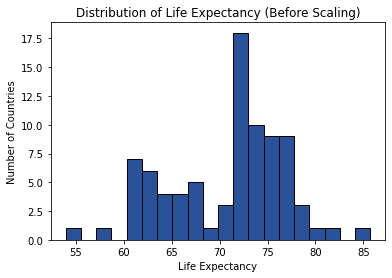

In [39]:
plt.figure(figsize=(6, 4))
plt.hist(df["LifeExpectancy"], bins=20, color='#2a5298' , edgecolor='black')
plt.title("Distribution of Life Expectancy (Before Scaling)")
plt.xlabel("Life Expectancy")
plt.ylabel("Number of Countries")
plt.show()

### PART 2 : Elbow Method

c:\ProgramData\Anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1036: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


k	WCSS
1 	 335.99999999999994
2 	 206.43717192603816
3 	 140.44737992159946
4 	 84.95472291479635
5 	 65.11528215592145
6 	 53.527519913854
7 	 46.05898656569733
8 	 36.04848601876525
9 	 30.437041739777428
10 	 26.901557023341667


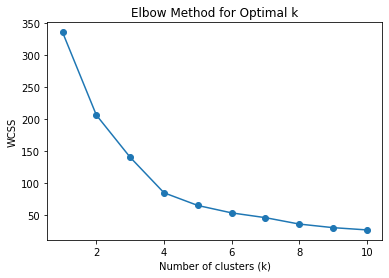

In [40]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

print("k\tWCSS")
for i in range(10):
    print(i+1, "\t", wcss[i])

plt.plot(range(1, 11), wcss, marker='o')   
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.show()        

### PART 3 : Clustering Algorithms

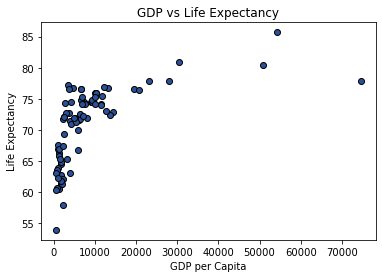

In [41]:
plt.scatter(df["GDP"], df["LifeExpectancy"], color='#2a5298', edgecolor='black')
plt.title("GDP vs Life Expectancy")
plt.xlabel("GDP per Capita")
plt.ylabel("Life Expectancy")  
plt.show()

In [42]:
kmeans = KMeans(n_clusters=5, random_state=42)
labels_km = kmeans.fit_predict(scaled_data)

df['KMeans_Cluster'] = labels_km

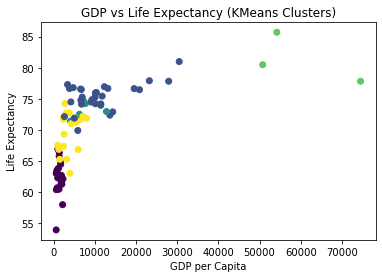

In [43]:
plt.scatter(df["GDP"], df["LifeExpectancy"], c=labels_km )
plt.title("GDP vs Life Expectancy (KMeans Clusters)")   
plt.xlabel("GDP per Capita")
plt.ylabel("Life Expectancy")
plt.show()

In [44]:
hc = AgglomerativeClustering(n_clusters=5)
labels_hc = hc.fit_predict(scaled_data)

df["Heirarchical_Cluster"] = labels_hc

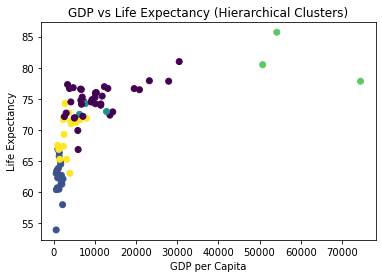

In [45]:
plt.scatter(df["GDP"], df["LifeExpectancy"], c=labels_hc)
plt.title("GDP vs Life Expectancy (Hierarchical Clusters)")
plt.xlabel("GDP per Capita")
plt.ylabel("Life Expectancy")
plt.show()

In [46]:
cluster_summary = df.groupby('KMeans_Cluster').mean()[['GDP', 'Population', 'LifeExpectancy', 'LiteracyRate']]
print(cluster_summary)

                         GDP    Population  LifeExpectancy  LiteracyRate
KMeans_Cluster                                                          
0                1341.622434  6.419319e+08       62.347536     62.743471
1               10816.834706  4.765712e+08       75.276053     96.051522
2                7094.638897  5.911254e+09       72.421619     86.116721
3               59828.745744  1.277089e+08       81.342589     98.996384
4                3701.959765  4.723799e+08       69.845358     80.968718


In [53]:
for country_name in ["India","North America", "Brazil"]:
    result = df.loc[country_name]

    print(f"Country: {country_name}")
    print(f"GDP per Capita: {result['GDP']}")
    print(f"Population: {result['Population']}")
    print(f"Life Expectancy: {result['LifeExpectancy']}")
    print(f"Literacy Rate: {result['LiteracyRate']}")
    print(f"KMeans Cluster: {result['KMeans_Cluster']}")
    print(f"Hierarchical Cluster: {result['Heirarchical_Cluster']}")
    print("-" * 40)

Country: India
GDP per Capita: 2347.44829434623
Population: 1425423212.0
Life Expectancy: 71.698
Literacy Rate: 76.3199996948242
KMeans Cluster: 4.0
Hierarchical Cluster: 4.0
----------------------------------------
Country: North America
GDP per Capita: 74535.6365392629
Population: 373018004.0
Life Expectancy: 77.8327679594239
Literacy Rate: 98.7891464233398
KMeans Cluster: 3.0
Hierarchical Cluster: 3.0
----------------------------------------
Country: Brazil
GDP per Capita: 9281.33282136864
Population: 210306415.0
Life Expectancy: 74.872
Literacy Rate: 94.3853874531348
KMeans Cluster: 1.0
Hierarchical Cluster: 0.0
----------------------------------------


In [56]:
for country_name in [ "Viet Nam", "Bahrain"]:
    result = df.loc[country_name]

    print(f"Country: {country_name}")
    print(f"GDP per Capita: {result['GDP']}")
    print(f"Population: {result['Population']}")
    print(f"Life Expectancy: {result['LifeExpectancy']}")
    print(f"Literacy Rate: {result['LiteracyRate']}")
    print(f"KMeans Cluster: {result['KMeans_Cluster']}")
    print(f"Hierarchical Cluster: {result['Heirarchical_Cluster']}")
    print("-" * 40)

Country: Viet Nam
GDP per Capita: 4147.69777213621
Population: 99680655.0
Life Expectancy: 74.502
Literacy Rate: 96.129997253418
KMeans Cluster: 1.0
Hierarchical Cluster: 0.0
----------------------------------------
Country: Bahrain
GDP per Capita: 30470.5219276023
Population: 1524693.0
Life Expectancy: 80.992
Literacy Rate: 97.870002746582
KMeans Cluster: 1.0
Hierarchical Cluster: 0.0
----------------------------------------
